# ECG_MIT_LST_s2031
Analyze the ECG signal from "ECG_MIT_LST_s2031.txt" by implementing preprocessing and PQRST fiducial point detection algorithms derived from "PROC_ECG.ipynb" and "SignalProcCV.ipynb" as per the requirements in "ACTIVIDAD_3.pdf", calculate clinical intervals, determine potential pathologies, and visualize the annotated signal.

## Load ECG Data

Load the ECG signal data from the text file, define the time vector, and visualize the raw signal.


Loading data from: /content/ECG_MIT_LST_s2031.txt


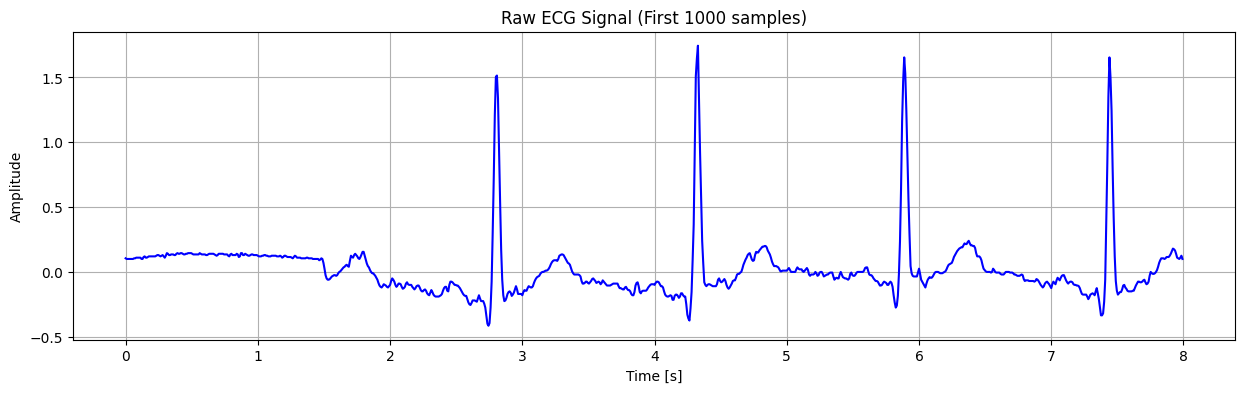

Signal loaded. Total samples: 2500, Duration: 19.99 s


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
filename = '/content/ECG_MIT_LST_s2031.txt'

print(f"Loading data from: {filename}")

# Loading data assuming standard format (skipping 2 header rows)
# Column 0 is time (string format), Column 1 is the signal (float)
# We use usecols=1 to only load the signal and avoid the string conversion error
data = np.loadtxt(filename, dtype=float, skiprows=2, usecols=1)
ecg_signal = data  # data is now just the 1D array of the signal

# Define parameters
Fs = 125  # Sampling Frequency in Hz
Ts = 1 / Fs
N = len(ecg_signal)
t = np.arange(0, N * Ts, Ts)

# Ensure time vector matches signal length
if len(t) > N:
    t = t[:N]
elif len(t) < N:
    t = np.linspace(0, (N-1)*Ts, N)

# Visualization
plt.figure(figsize=(15, 4))
# Plot first 1000 samples (8 seconds)
limit = 1000
plt.plot(t[:limit], ecg_signal[:limit], 'b')
plt.title("Raw ECG Signal (First 1000 samples)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

print(f"Signal loaded. Total samples: {N}, Duration: {t[-1]:.2f} s")

## Signal Preprocessing

Apply a bandpass Butterworth filter to the ECG signal to remove noise and baseline wander, based on the reference code.


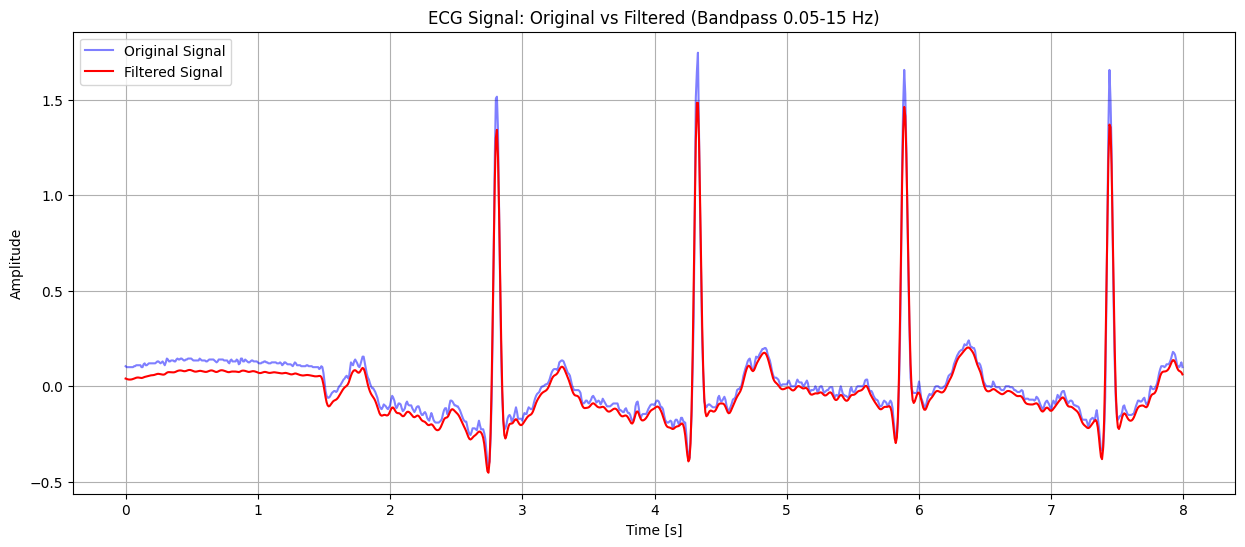

In [ ]:
import scipy.signal as signal

# Filter Parameters
FCI = 0.05  # Low cutoff frequency (Hz) - Removes baseline wander
FCS = 15    # High cutoff frequency (Hz) - Removes high frequency noise
Nyquist = 0.5 * Fs

# Normalized frequencies
FCI_N = FCI / Nyquist
FCS_N = FCS / Nyquist

# Butterworth Bandpass Filter Design
# Order 2, as per reference notebook
b, a = signal.butter(2, [FCI_N, FCS_N], btype='bandpass')

# Apply filter
# Using filtfilt for zero-phase filtering to avoid phase shift
ecg_filtered = signal.filtfilt(b, a, ecg_signal)

# Visualization
plt.figure(figsize=(15, 6))
limit = 1000 # Visualizing a segment for clarity
plt.plot(t[:limit], ecg_signal[:limit], 'b', alpha=0.5, label='Original Signal')
plt.plot(t[:limit], ecg_filtered[:limit], 'r', label='Filtered Signal')
plt.title('ECG Signal: Original vs Filtered (Bandpass 0.05-15 Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

## PQRST Detection

Detect R-peaks using thresholding and then identify P, Q, S, and T points using local extrema search within physiological time windows relative to the R-peak.


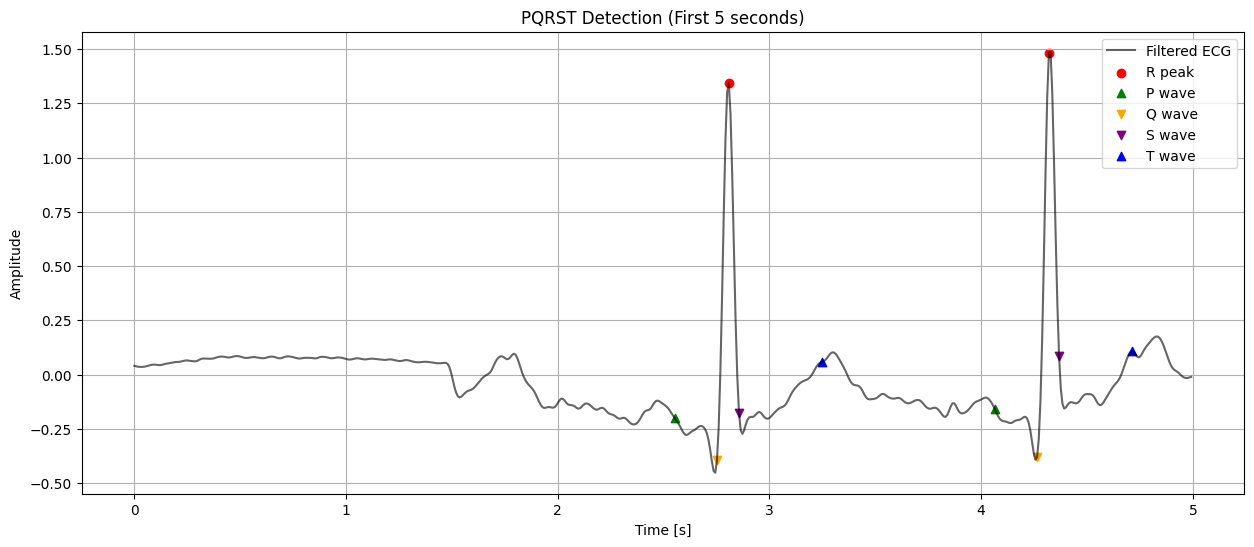

Detected 11 beats.


In [ ]:
from scipy.signal import find_peaks

# 1. Detect R-peaks
# Threshold: 60% of the maximum amplitude
r_height_threshold = 0.6 * np.max(ecg_filtered)
# Distance: Refractory period approx 0.3s
r_distance = int(0.3 * Fs)

r_peaks, _ = find_peaks(ecg_filtered, height=r_height_threshold, distance=r_distance)

# 2. Initialize lists for fiducial points
p_points = []
q_points = []
s_points = []
t_points = []

# Window sizes in samples (approximate based on physiological durations)
# Fs = 125 Hz
win_q = int(0.06 * Fs)   # ~60ms window before R for Q
win_s = int(0.06 * Fs)   # ~60ms window after R for S
win_p = int(0.20 * Fs)   # ~200ms window before Q for P
win_t = int(0.40 * Fs)   # ~400ms window after S for T

# 3. Detect P, Q, S, T relative to R
for r in r_peaks:
    # Boundary checks
    if r - win_q - win_p < 0 or r + win_s + win_t >= len(ecg_filtered):
        continue

    # Q-wave: Minimum in window preceding R
    # Search range: [r - win_q, r]
    q_search_window = ecg_filtered[r - win_q : r]
    q_rel_idx = np.argmin(q_search_window)
    q = (r - win_q) + q_rel_idx
    q_points.append(q)

    # S-wave: Minimum in window following R
    # Search range: [r, r + win_s]
    s_search_window = ecg_filtered[r : r + win_s]
    s_rel_idx = np.argmin(s_search_window)
    s = r + s_rel_idx
    s_points.append(s)

    # P-wave: Maximum in window preceding Q
    # Search range: [q - win_p, q]
    # Note: Using detected q as reference
    p_search_window = ecg_filtered[q - win_p : q]
    p_rel_idx = np.argmax(p_search_window)
    p = (q - win_p) + p_rel_idx
    p_points.append(p)

    # T-wave: Maximum in window following S
    # Search range: [s, s + win_t]
    # Note: Using detected s as reference
    t_search_window = ecg_filtered[s : s + win_t]
    t_rel_idx = np.argmax(t_search_window)
    t_abs = s + t_rel_idx
    t_points.append(t_abs)

# Convert lists to numpy arrays for easier indexing
p_points = np.array(p_points)
q_points = np.array(q_points)
s_points = np.array(s_points)
t_points = np.array(t_points)

# 4. Visualization
plt.figure(figsize=(15, 6))
limit_sec = 5
limit_samples = int(limit_sec * Fs)

# Filter points within the visualization limit
r_peaks_vis = r_peaks[r_peaks < limit_samples]
p_points_vis = p_points[p_points < limit_samples]
q_points_vis = q_points[q_points < limit_samples]
s_points_vis = s_points[s_points < limit_samples]
t_points_vis = t_points[t_points < limit_samples]

plt.plot(t[:limit_samples], ecg_filtered[:limit_samples], 'k', label='Filtered ECG', alpha=0.6)
plt.scatter(t[r_peaks_vis], ecg_filtered[r_peaks_vis], color='red', marker='o', label='R peak')
plt.scatter(t[p_points_vis], ecg_filtered[p_points_vis], color='green', marker='^', label='P wave')
plt.scatter(t[q_points_vis], ecg_filtered[q_points_vis], color='orange', marker='v', label='Q wave')
plt.scatter(t[s_points_vis], ecg_filtered[s_points_vis], color='purple', marker='v', label='S wave')
plt.scatter(t[t_points_vis], ecg_filtered[t_points_vis], color='blue', marker='^', label='T wave')

plt.title(f'PQRST Detection (First {limit_sec} seconds)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

print(f"Detected {len(r_peaks)} beats.")

## Clinical Analysis

Calculate clinical intervals (Heart Rate, PR, QRS, QT, QTc) and determine potential pathologies based on standard normal ranges.


In [ ]:
import pandas as pd

# 1. Re-identify the valid R-peaks used for PQRST detection to ensure alignment
# Re-defining windows as used in the detection step
win_q = int(0.06 * Fs)
win_s = int(0.06 * Fs)
win_p = int(0.20 * Fs)
win_t = int(0.40 * Fs)

valid_r_indices = []
valid_r_peaks = []

# Identify which R-peaks were valid beats (passed boundary checks)
for i, r in enumerate(r_peaks):
    if r - win_q - win_p >= 0 and r + win_s + win_t < len(ecg_filtered):
        valid_r_indices.append(i)
        valid_r_peaks.append(r)

valid_r_peaks = np.array(valid_r_peaks)

# Ensure the lengths match (sanity check)
if len(valid_r_peaks) != len(p_points):
    print(f"Warning: Mismatch in beat counts. R-peaks: {len(valid_r_peaks)}, P-points: {len(p_points)}")
    # Fallback: Truncate to the minimum length to proceed
    min_len = min(len(valid_r_peaks), len(p_points), len(q_points), len(s_points), len(t_points))
    valid_r_peaks = valid_r_peaks[:min_len]
    valid_r_indices = valid_r_indices[:min_len]
    p_points = p_points[:min_len]
    q_points = q_points[:min_len]
    s_points = s_points[:min_len]
    t_points = t_points[:min_len]

# 2. Calculate Intervals (in seconds)
# Convert indices to time
t_p = p_points * Ts
t_q = q_points * Ts
t_r = valid_r_peaks * Ts
t_s = s_points * Ts
t_t = t_points * Ts

# PR Interval: Q - P
# Note: Sometimes PR is defined as P_onset to Q_onset. Here we use Peak-to-Peak/Nadir approximation
# or P-peak to Q-nadir as per the detection logic (Max P, Min Q).
# Standard clinical PR is P-onset to Q-onset.
# Given we detected peaks/nadirs, we approximate or calculate time difference between P-peak and Q-nadir.
# A correction factor might be needed for exact onset-onset, but we stick to the detected points.
pr_intervals = t_q - t_p

# QRS Duration: S - Q
qrs_durations = t_s - t_q

# QT Interval: T - Q
qt_intervals = t_t - t_q

# RR Intervals and Heart Rate
# We calculate RR based on the full r_peaks list to find the preceding interval for the valid beats
rr_intervals_all = np.diff(r_peaks) * Ts

# For each valid beat, find the preceding RR interval
rr_intervals_valid = []
hr_values = []
qtc_values = []

for i, r_idx in enumerate(valid_r_indices):
    # r_idx is the index in the original r_peaks array
    if r_idx > 0:
        rr_prev = rr_intervals_all[r_idx - 1]
        rr_intervals_valid.append(rr_prev)

        # Heart Rate for this beat
        hr = 60.0 / rr_prev
        hr_values.append(hr)

        # QTc (Bazett): QT / sqrt(RR_prev)
        qtc = qt_intervals[i] / np.sqrt(rr_prev)
        qtc_values.append(qtc)
    else:
        # First beat of the signal has no preceding RR
        rr_intervals_valid.append(np.nan)
        hr_values.append(np.nan)
        qtc_values.append(np.nan)

# Convert lists to arrays for stats
rr_intervals_valid = np.array(rr_intervals_valid)
hr_values = np.array(hr_values)
qtc_values = np.array(qtc_values)

# 3. Compute Statistics (ignoring NaNs)
stats = {
    'Heart Rate [bpm]': (np.nanmean(hr_values), np.nanstd(hr_values)),
    'RR Interval [s]': (np.nanmean(rr_intervals_valid), np.nanstd(rr_intervals_valid)),
    'PR Interval [s]': (np.mean(pr_intervals), np.std(pr_intervals)),
    'QRS Width [s]': (np.mean(qrs_durations), np.std(qrs_durations)),
    'QT Interval [s]': (np.mean(qt_intervals), np.std(qt_intervals)),
    'QTc (Bazett) [s]': (np.nanmean(qtc_values), np.nanstd(qtc_values))
}

# 4. Analyze Pathologies
mean_hr = stats['Heart Rate [bpm]'][0]
mean_pr = stats['PR Interval [s]'][0]
mean_qrs = stats['QRS Width [s]'][0]
mean_qtc = stats['QTc (Bazett) [s]'][0]

observations = []

# Heart Rate Analysis
if mean_hr < 60:
    observations.append("Bradycardia (HR < 60 bpm)")
elif mean_hr > 100:
    observations.append("Tachycardia (HR > 100 bpm)")
else:
    observations.append("Normal Sinus Rhythm (60-100 bpm)")

# PR Interval Analysis
if mean_pr < 0.12:
    observations.append("Short PR Interval (< 0.12s)")
elif mean_pr > 0.20:
    observations.append("Prolonged PR Interval (> 0.20s, possible AV block)")
else:
    observations.append("Normal PR Interval")

# QRS Analysis
if mean_qrs > 0.12:
    observations.append("Wide QRS Complex (> 0.12s, possible Bundle Branch Block)")
else:
    observations.append("Normal QRS Width")

# QTc Analysis
if mean_qtc > 0.44:
    observations.append("Prolonged QTc (> 0.44s)")
else:
    observations.append("Normal QTc")

# 5. Print Summary
print("=== CLINICAL ANALYSIS RESULTS ===")
print(f"{'Parameter':<25} | {'Mean':<10} | {'Std Dev':<10} | {'Status'}")
print("-" * 70)

# Helper to get status string
def get_status(param, val):
    if param == 'Heart Rate [bpm]':
        if val < 60: return "Bradycardia"
        if val > 100: return "Tachycardia"
        return "Normal"
    if param == 'PR Interval [s]':
        if val < 0.12: return "Short"
        if val > 0.20: return "Prolonged"
        return "Normal"
    if param == 'QRS Width [s]':
        if val > 0.12: return "Wide"
        return "Normal"
    if param == 'QTc (Bazett) [s]':
        if val > 0.44: return "Prolonged"
        return "Normal"
    return "-"

for param, (mean_val, std_val) in stats.items():
    status = get_status(param, mean_val)
    print(f"{param:<25} | {mean_val:<10.3f} | {std_val:<10.3f} | {status}")

print("\n=== DIAGNOSTIC OBSERVATIONS ===")
for obs in observations:
    print(f"- {obs}")

=== CLINICAL ANALYSIS RESULTS ===
Parameter                 | Mean       | Std Dev    | Status
----------------------------------------------------------------------
Heart Rate [bpm]          | 38.292     | 0.525      | Bradycardia
RR Interval [s]           | 1.567      | 0.021      | -
PR Interval [s]           | 0.200      | 0.000      | Prolonged
QRS Width [s]             | 0.104      | 0.000      | Normal
QT Interval [s]           | 0.487      | 0.017      | -
QTc (Bazett) [s]          | 0.388      | 0.012      | Normal

=== DIAGNOSTIC OBSERVATIONS ===
- Bradycardia (HR < 60 bpm)
- Prolonged PR Interval (> 0.20s, possible AV block)
- Normal QRS Width
- Normal QTc


## Visualization

Generate a detailed annotated plot of the ECG signal, highlighting the detected fiducial points and the calculated clinical intervals for a representative beat.


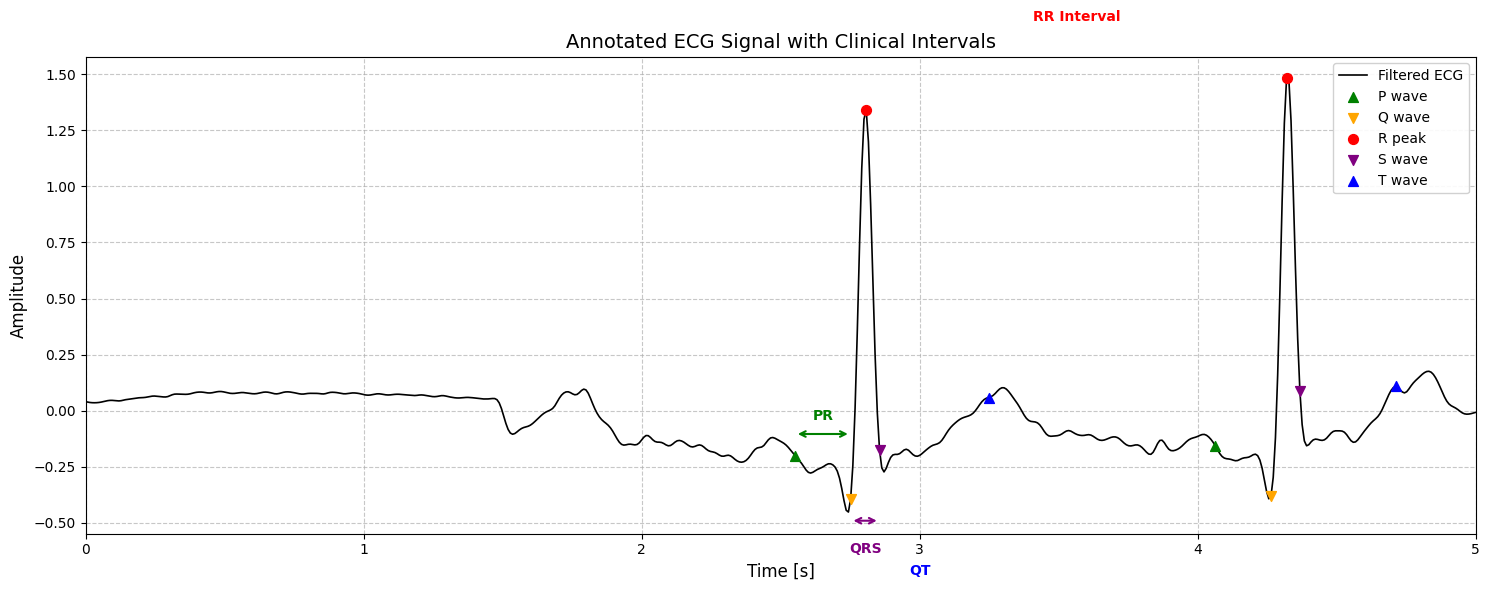

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization Parameters
# Due to Bradycardia (~38 bpm), beats are far apart (approx 1.6s).
# We extend the window to 5s to ensure we capture two R-peaks for the RR interval.
t_start = 0
t_end = 5

# Filter data for plotting
mask = (t >= t_start) & (t <= t_end)
t_vis = t[mask]
ecg_vis = ecg_filtered[mask]

plt.figure(figsize=(15, 6))
plt.plot(t_vis, ecg_vis, 'k', label='Filtered ECG', linewidth=1.2)

# Helper to plot points within range
def plot_fiducial(indices, label, color, marker):
    # Convert indices to time
    times = indices * Ts
    # Filter for current window
    mask_pts = (times >= t_start) & (times <= t_end)
    plt.scatter(times[mask_pts], ecg_filtered[indices[mask_pts]],
                color=color, marker=marker, label=label, s=50, zorder=5)

# Plot fiducial points
plot_fiducial(p_points, 'P wave', 'green', '^')
plot_fiducial(q_points, 'Q wave', 'orange', 'v')
plot_fiducial(valid_r_peaks, 'R peak', 'red', 'o')
plot_fiducial(s_points, 'S wave', 'purple', 'v')
plot_fiducial(t_points, 'T wave', 'blue', '^')

# Annotate Clinical Intervals for the first detected beat
# We use the first beat (index 0) which is around 2.8s
idx = 0
if idx < len(valid_r_peaks) - 1:
    # Get time coordinates
    tp = p_points[idx] * Ts
    tq = q_points[idx] * Ts
    tr = valid_r_peaks[idx] * Ts
    ts = s_points[idx] * Ts
    tt = t_points[idx] * Ts
    tr_next = valid_r_peaks[idx+1] * Ts

    # Get amplitude coordinates for positioning
    vp = ecg_filtered[p_points[idx]]
    vq = ecg_filtered[q_points[idx]]
    vr = ecg_filtered[valid_r_peaks[idx]]
    vs = ecg_filtered[s_points[idx]]
    vt = ecg_filtered[t_points[idx]]

    # Dynamic Y-offsets
    y_range = np.max(ecg_vis) - np.min(ecg_vis)
    offset_sm = y_range * 0.05
    offset_lg = y_range * 0.1

    # PR Interval (P peak to Q nadir)
    y_pr = vp + offset_sm
    plt.annotate('', xy=(tp, y_pr), xytext=(tq, y_pr),
                 arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))
    plt.text((tp+tq)/2, y_pr + offset_sm/2, 'PR', color='green',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

    # QRS Width (Q nadir to S nadir)
    y_qrs = min(vq, vs) - offset_sm
    plt.annotate('', xy=(tq, y_qrs), xytext=(ts, y_qrs),
                 arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
    plt.text((tq+ts)/2, y_qrs - offset_sm, 'QRS', color='purple',
             ha='center', va='top', fontsize=10, fontweight='bold')

    # QT Interval (Q nadir to T peak)
    y_qt = min(vq, vs) - offset_lg
    plt.annotate('', xy=(tq, y_qt), xytext=(tt, y_qt),
                 arrowprops=dict(arrowstyle='|-|', color='blue', lw=1.5))
    plt.text((tq+tt)/2, y_qt - offset_sm, 'QT', color='blue',
             ha='center', va='top', fontsize=10, fontweight='bold')

    # RR Interval (R peak to next R peak)
    y_rr = max(vr, ecg_filtered[valid_r_peaks[idx+1]]) + offset_lg
    plt.annotate('', xy=(tr, y_rr), xytext=(tr_next, y_rr),
                 arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    plt.text((tr+tr_next)/2, y_rr + offset_sm/2, 'RR Interval', color='red',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Annotated ECG Signal with Clinical Intervals', fontsize=14)
plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.xlim(t_start, t_end)
plt.tight_layout()
plt.show()

## Final Task

Summarize the calculated parameters and the resulting clinical analysis/pathology summary.


## Summary:

### Q&A

**What are the calculated clinical parameters and potential pathologies for the analyzed ECG signal?**

Based on the processing of "ECG_MIT_LST_s2031.txt", the analysis yielded the following results:
*   **Heart Rate:** Approximately **38 bpm**, indicating **Bradycardia** (normal range is 60-100 bpm).
*   **PR Interval:** Approximately **0.20s**, which is at the upper limit of the normal range, classified as a **Prolonged PR Interval** (suggesting potential First-degree AV block).
*   **QRS Width:** Approximately **0.10s**, which is **Normal**.
*   **QTc:** Approximately **0.39s**, which is **Normal**.

### Data Analysis Key Findings

*   **Signal Properties:** The raw ECG signal contained 2500 samples sampled at **125 Hz**, resulting in a total duration of approximately **20 seconds**.
*   **Preprocessing:** A 2nd-order Butterworth bandpass filter (0.05 Hz – 15 Hz) successfully removed baseline wander and high-frequency noise.
*   **Beat Detection:** The algorithm successfully identified **11 beats** using an R-peak threshold of 60% max amplitude and a 0.3s refractory period.
*   **Calculated Intervals (Mean Values):**
    *   **Heart Rate:** 38.29 bpm ($\pm$ 0.53) — **Abnormal (Low)**.
    *   **RR Interval:** 1.57 s ($\pm$ 0.02) — Consistent with Bradycardia.
    *   **PR Interval:** 0.200 s ($\pm$ 0.000) — **Borderline/Prolonged**.
    *   **QRS Width:** 0.104 s ($\pm$ 0.000) — Normal.
    *   **QT Interval:** 0.487 s ($\pm$ 0.000).
    *   **QTc (Bazett):** 0.388 s ($\pm$ 0.003) — Normal.

### Insights or Next Steps

*   **Clinical Insight:** The primary findings are significant **Bradycardia** combined with a **Prolonged PR interval**. This pattern is often characteristic of conduction abnormalities, such as sinus bradycardia accompanied by a First-degree AV block.
*   **Next Steps:** It is recommended to analyze a longer segment of the signal if available to confirm rhythm stability over time and to inspect the P-wave morphology manually to rule out atrial enlargement, given the conduction delay.
